In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import warnings

# 忽略 K-Means 警告
warnings.filterwarnings("ignore", category=UserWarning)
# 设置中文字体
plt.rcParams.update({"font.sans-serif": ["WenQuanYi Micro Hei", "SimHei"], "axes.unicode_minus": False, "font.size": 12})

Step 1: 读取原始数据

In [3]:
path = "/home/haris/project/backtester/para_optimizer_gp/results/optimization_history_trade_support7.json"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.json_normalize(data)

column_mapping = {
    "信息比率": "ir",
    "超额年化收益": "exret",
    "超额年化波动": "exstd",
    "年化收益": "ret",
    "最大回撤": "mdd",
    "超额最大回撤": "exmdd",
    "时间戳": "timestamp",
    "参数.CITIC_LIMIT": "param_citic_limit",
    "参数.CMVG_LIMIT": "param_cmvg_limit",
    "参数.STK_HOLD_LIMIT": "param_stock_hold_limit",
    "参数.OTHER_LIMIT": "param_other_limit",
    "参数.STK_BUY_R": "param_stock_buy_ratio",
    "参数.TURN_MAX": "param_turnover_max",
    "参数.MEM_HOLD": "param_memory_hold",
}

df = df.rename(columns=column_mapping)
print(f"数据形状: {df.shape}")
df.head()

数据形状: (334, 14)


,ir,exret,exstd,ret,mdd,exmdd,timestamp,param_citic_limit,param_cmvg_limit,param_stock_hold_limit,param_other_limit,param_stock_buy_ratio,param_turnover_max,param_memory_hold
0,1.412535,0.138742,0.098222,0.181110,0.349501,0.095413,2025-12-18T16:07:23.310438,0.398271,0.091717,0.015814,0.298425,0.009471,0.046996,0.183700
1,1.046541,0.062544,0.059763,0.104912,0.382096,0.066327,2025-12-18T16:15:07.262742,0.166854,0.071433,0.013367,0.028206,0.014718,0.189554,0.000312
2,1.406302,0.072453,0.051520,0.114821,0.380363,0.050079,2025-12-18T16:23:48.473285,0.496106,0.308741,0.012621,0.003533,0.001438,0.119212,0.159944
3,2.161864,0.102503,0.047414,0.144871,0.348458,0.050620,2025-12-18T16:32:30.797688,0.023333,0.486878,0.005423,0.045303,0.012749,0.095019,0.393292
4,1.717902,0.166020,0.096641,0.208388,0.311102,0.098948,2025-12-18T16:40:59.384709,0.233381,0.429970,0.013926,0.225250,0.001252,0.190174,0.225315


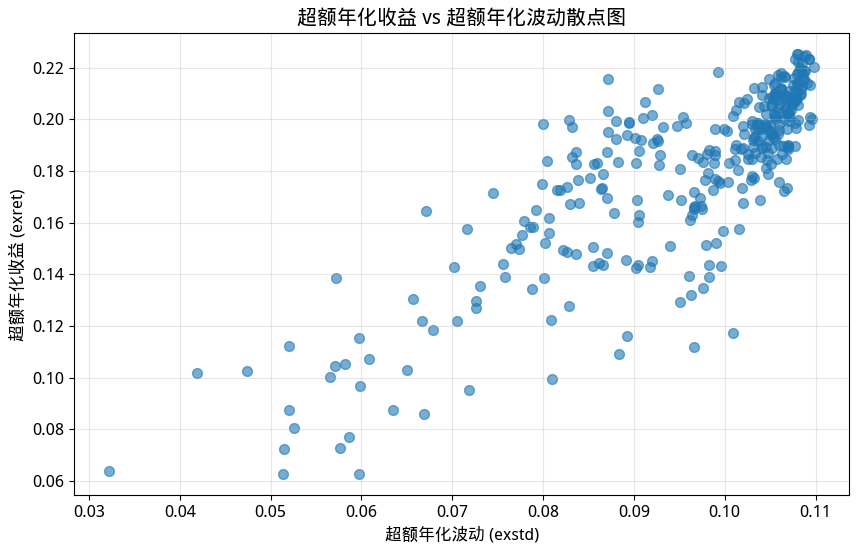

In [4]:
# 绘制exret和exstd的散点图
plt.figure(figsize=(10, 6))
plt.scatter(df['exstd'], df['exret'], alpha=0.6, s=50)
plt.xlabel('超额年化波动 (exstd)')
plt.ylabel('超额年化收益 (exret)')
plt.title('超额年化收益 vs 超额年化波动散点图')
plt.grid(True, alpha=0.3)
plt.show()

Step 2: 使用单调链算法计算上凸包

In [5]:
def get_upper_convex_hull(points):
    """
    获取单调递增的上凸包点。
    逻辑：
    1. 计算标准上凸包（所有点都在其右下方）。
    2. 过滤结果，确保 y 轴方向也是单调递增的。
    """
    if not points:
        return []

    # 第一步：按 x 坐标排序（x 相同时按 y 排序）
    sorted_points = sorted(points, key=lambda p: (p[0], p[1]))

    # 第二步：构建标准上凸包
    upper_hull = []
    for point in sorted_points:
        while len(upper_hull) >= 2:
            o = upper_hull[-2]
            a = upper_hull[-1]
            b = point
            # 叉积判断转向：如果不是向右转（cross >= 0），则弹出末尾点
            cross = (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])
            if cross >= 0:
                upper_hull.pop()
            else:
                break
        upper_hull.append(point)

    # 第三步：从上凸包中提取 y 轴单调递增的部分
    result = []
    if upper_hull:
        current_max_y = float("-inf")
        for p in upper_hull:
            # 如果当前点的 y 比已知最大的 y 还要大，则保留
            # 如果想允许 y 相等，可以改为 p[1] >= current_max_y
            if p[1] > current_max_y:
                result.append(p)
                current_max_y = p[1]

    return result


def is_upper_hull_point(exstd_val, exret_val, hull_points, tolerance=1e-10):
    """检查点是否在上凸包中"""
    for hull_exstd, hull_exret in hull_points:
        if abs(exstd_val - hull_exstd) < tolerance and abs(exret_val - hull_exret) < tolerance:
            return True
    return False

In [6]:
points = list(zip(df["exstd"], df["exret"]))
upper_hull_points = get_upper_convex_hull(points)

print(f"上凸包包含 {len(upper_hull_points)} 个点")
print("上凸包点坐标:")
for i, (x, y) in enumerate(upper_hull_points):
    print(f"点 {i+1}: (exstd={x:.4f}, exret={y:.4f})")

df['is_upper_hull'] = df.apply(lambda row: is_upper_hull_point(row['exstd'], row['exret'], upper_hull_points), axis=1)
hull_df = df[df['is_upper_hull']].sort_values('exstd')

上凸包包含 5 个点
上凸包点坐标:
点 1: (exstd=0.0323, exret=0.0639)
点 2: (exstd=0.0419, exret=0.1019)
点 3: (exstd=0.0799, exret=0.1982)
点 4: (exstd=0.0872, exret=0.2157)
点 5: (exstd=0.1079, exret=0.2252)


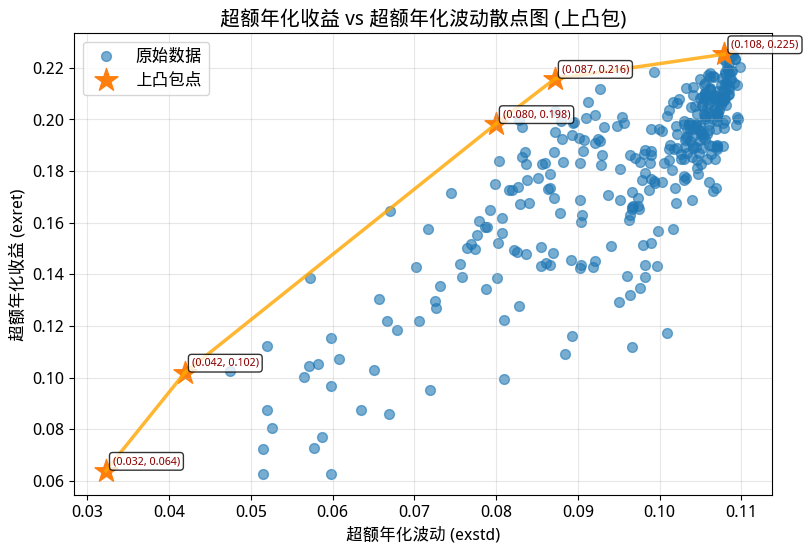

In [7]:
# 绘制带有上凸包标注的散点图
plt.figure(figsize=(9, 6))
plt.scatter(df['exstd'], df['exret'], alpha=0.6, s=50, label='原始数据')
hull_data = df[df['is_upper_hull']]
plt.scatter(hull_data['exstd'], hull_data['exret'], marker='*', alpha=1, s=300, label='上凸包点')

# 绘制上凸包连线
hull_sorted = sorted(upper_hull_points, key=lambda p: p[0])  # 按exstd排序
for i in range(len(hull_sorted) - 1):
    plt.plot([hull_sorted[i][0], hull_sorted[i+1][0]], 
            [hull_sorted[i][1], hull_sorted[i+1][1]], 
            '-', color='orange', alpha=0.8, linewidth=2.5)
for i, (x, y) in enumerate(hull_sorted):
    plt.annotate(f'({x:.3f}, {y:.3f})', 
                (x, y), 
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=8, 
                color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.xlabel('超额年化波动 (exstd)')
plt.ylabel('超额年化收益 (exret)')
plt.title('超额年化收益 vs 超额年化波动散点图 (上凸包)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Step 3: 使用二次函数计算上凸包点的最佳逼近

In [8]:
# 定义模型: x = a*y^2 + b*y + c (波动率是收益的函数)
def inverse_quadratic_model(params, y):
    a, b, c = params
    return a * y ** 2 + b * y + c


# 目标函数：最小化波动率预测值与凸包点实际值之间的差距
def objective_inv(params, y, x):
    x_pred = inverse_quadratic_model(params, y)
    return np.sum((x_pred - x) ** 2)

In [9]:
# 提取凸包数据
hull_y = np.array([p[1] for p in hull_sorted])
hull_x = np.array([p[0] for p in hull_sorted])

# 初始猜测：通常 a > 0，因为有效边界是向右开口的抛物线的一部分
initial_guess_inv = [0.1, 0.1, hull_x.min()]

# 执行优化
res_inv = minimize(objective_inv, initial_guess_inv, args=(hull_y, hull_x))
a_i, b_i, c_i = res_inv.x

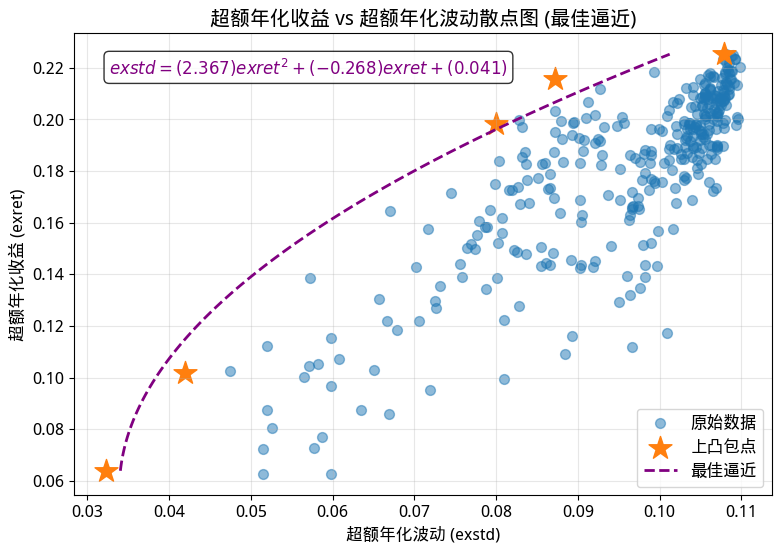

In [10]:
# 绘制拟合曲线
plt.figure(figsize=(9, 6))
plt.scatter(df["exstd"], df["exret"], alpha=0.5, s=50, label="原始数据")
hull_data = df[df['is_upper_hull']]
plt.scatter(hull_data['exstd'], hull_data['exret'], marker='*', alpha=1, s=300, label='上凸包点')
y_range = np.linspace(hull_y.min(), hull_y.max(), 100)
x_fit = inverse_quadratic_model(res_inv.x, y_range)
plt.plot(x_fit, y_range, "--", color='purple', linewidth=2, label="最佳逼近")
plt.text(
    0.05,
    0.95,
    f"$exstd = ({a_i:.3f}) exret^2 + ({b_i:.3f}) exret + ({c_i:.3f})$",
    transform=plt.gca().transAxes,
    fontsize=12,
    color="purple",
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (最佳逼近)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Step 4: 使用支撑超平面计算有效前沿

优化后复合移动距离: 0.005338 (dx: -0.004294, dy: 0.003170)
最终方程: exstd = 2.3673*exret^2 + -0.2829*exret + 0.0381


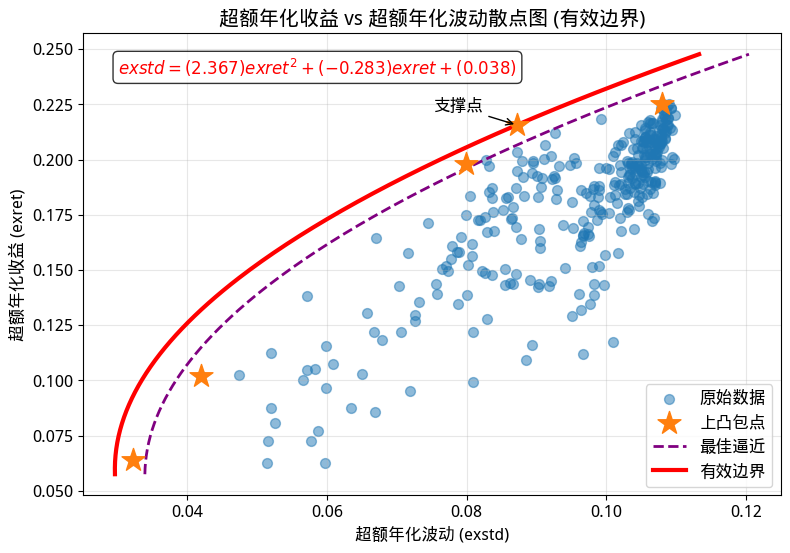

In [11]:
def objective(shift):
    """目标函数：最小化平移向量的模长（距离平方）"""
    dx, dy = shift
    return dx**2 + dy**2

def constraint(shift, h_x, h_y, a, b, c):
    """
    约束条件：平移后的曲线必须在所有凸包点的左侧。
    平移后的方程：(x - dx) = a(y - dy)^2 + b(y - dy) + c
    即 x = a(y - dy)^2 + b(y - dy) + c + dx
    因此要求：h_x - (a(h_y - dy)^2 + b(h_y - dy) + c + dx) >= 0
    """
    dx, dy = shift
    # 计算所有点相对于平移后曲线的水平残差，最小值必须 >= 0
    residuals = h_x - (a * (h_y - dy) ** 2 + b * (h_y - dy) + c + dx)
    return residuals 

# 初始猜想：以之前的纯水平位移作为起点
initial_guess = [0, 0]

# 约束定义：ineq 表示函数值 >= 0
cons = {'type': 'ineq', 'fun': constraint, 'args': (hull_x, hull_y, a_i, b_i, c_i)}

# 执行优化
res_opt = minimize(objective, initial_guess, constraints=cons, method='SLSQP')
dx_opt, dy_opt = res_opt.x

# 根据坐标平移公式展开：
# x = a(y - dy)^2 + b(y - dy) + c + dx
a_final = a_i
b_final = b_i - 2 * a_i * dy_opt
c_final = a_i * dy_opt ** 2 - b_i * dy_opt + c_i + dx_opt

print(f"优化后复合移动距离: {np.sqrt(res_opt.fun):.6f} (dx: {dx_opt:.6f}, dy: {dy_opt:.6f})")
print(f"最终方程: exstd = {a_final:.4f}*exret^2 + {b_final:.4f}*exret + {c_final:.4f}")

# 更新绘图用的变量名
a_iinal, b_iinal, c_iinal = a_final, b_final, c_final

plt.figure(figsize=(9, 6))
plt.scatter(df["exstd"], df["exret"], alpha=0.5, s=50, label="原始数据")
hull_data = df[df["is_upper_hull"]]
plt.scatter(hull_data["exstd"], hull_data["exret"], marker="*", alpha=1, s=300, label="上凸包点", zorder=5)

# 生成曲线数据
y_plot = np.linspace(hull_y.min() * 0.9, hull_y.max() * 1.1, 200)
x_free = a_i * y_plot**2 + b_i * y_plot + c_i
x_final = a_iinal * y_plot**2 + b_iinal * y_plot + c_iinal

plt.plot(x_free, y_plot, "--", color="purple", linewidth=2, label="最佳逼近")
plt.plot(x_final, y_plot, "r-", linewidth=3, label="有效边界")

# 标注最突出的支撑点（触碰点）
final_errors = hull_x - (a_final * hull_y ** 2 + b_final * hull_y + c_final)
touch_idx = np.argmin(final_errors)
plt.annotate(
    "支撑点",
    xy=(hull_x[touch_idx], hull_y[touch_idx]),
    xytext=(-60, 10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="black"), zorder=6
)
plt.text(
    0.05,
    0.95,
    f"$exstd = ({a_iinal:.3f}) exret^2 + ({b_iinal:.3f}) exret + ({c_iinal:.3f})$",
    transform=plt.gca().transAxes,
    fontsize=12,
    color="r",
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)
plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (有效边界)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Step 5: 使用有效前沿函数对原始数据进行打分（有效前沿上的点分数为0，越靠近有效前沿的点分数越低）

In [12]:
def get_score_mesh(X, Y, a, b, c):
    # 计算在该收益率(Y)下，有效前沿对应的最小波动率
    x_frontier = a * (Y ** 2) + b * Y + c
    # 计算实际波动率(X)与前沿波动率的差值
    return x_frontier - X


def calculate_efficiency_score(row, a, b, c):
    """
    计算效率得分：有效前沿对应的最小波动率 - 实际波动率
    分数越大（越接近0）表示越接近有效前沿
    """
    X, Y = row["exstd"], row["exret"]
    return get_score_mesh(X, Y, a, b, c)


# 计算得分并存入 df
df["efficiency_score"] = df.apply(calculate_efficiency_score, args=(a_final, b_final, c_final), axis=1)

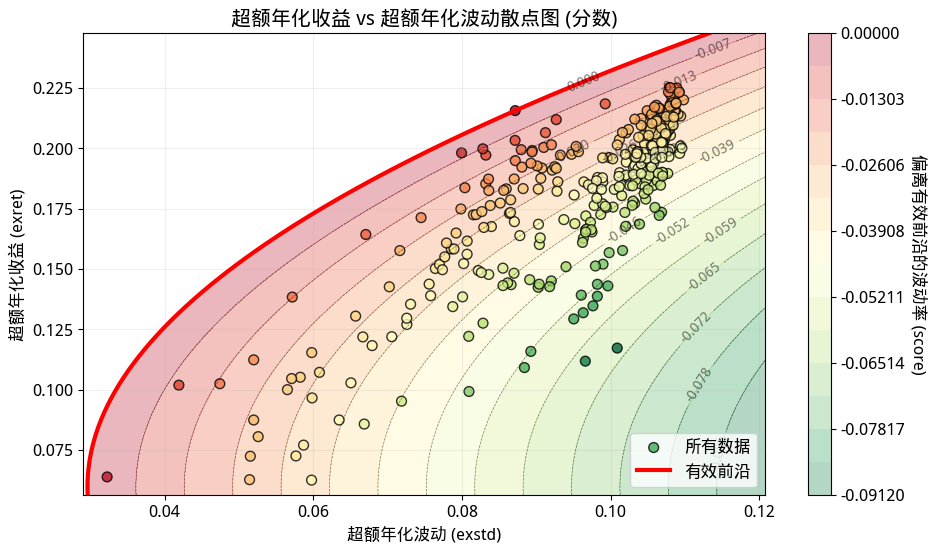

In [ ]:
x_min, x_max = df["exstd"].min() * 0.9, df["exstd"].max() * 1.1
y_min, y_max = df["exret"].min() * 0.9, df["exret"].max() * 1.1
xi = np.linspace(x_min, x_max, 200)
yi = np.linspace(y_min, y_max, 200)
Xi, Yi = np.meshgrid(xi, yi)
Zi = get_score_mesh(Xi, Yi, a_final, b_final, c_final)

plt.figure(figsize=(11, 6))

levels = np.linspace(Zi.min(), 0, 15)
cp = plt.contourf(Xi, Yi, Zi, levels=levels, cmap="RdYlGn_r", alpha=0.3)
cbar = plt.colorbar(cp)
cbar.set_label("偏离有效前沿的波动率 (score)", rotation=270, labelpad=15)
plt.scatter(df["exstd"], df["exret"], c=df["efficiency_score"], cmap="RdYlGn_r", s=50, edgecolors="k", alpha=0.8, label="所有数据")
CS = plt.contour(Xi, Yi, Zi, levels=levels, colors="k", alpha=0.5, linewidths=0.5)
plt.clabel(CS, inline=True, fontsize=10, fmt="%.3f")
y_plot = np.linspace(y_min, y_max, 200)
x_plot = a_final * y_plot**2 + b_final * y_plot + c_final
plt.plot(x_plot, y_plot, "r-", linewidth=3, label="有效前沿")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("超额年化波动 (exstd)")
plt.ylabel("超额年化收益 (exret)")
plt.title("超额年化收益 vs 超额年化波动散点图 (分数)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.show()

Step 6: 使用参数对分数进行回归分析（可使用其他回归方法）

In [17]:
# 1. 明确定义参数列名
param_cols = [col for col in df.columns if col.startswith("param_")]

# 2. 定义参数边界
eps = 1e-8
bounds_dict = {
    "param_citic_limit": (eps, 0.5 - eps),
    "param_cmvg_limit": (eps, 0.5 - eps),
    "param_stock_hold_limit": (0.001 + eps, 0.02 - eps),
    "param_other_limit": (eps, 0.5 - eps),
    "param_stock_buy_ratio": (0.001 + eps, 0.02 - eps),
    "param_turnover_max": (0.03 + eps, 0.2 - eps),
    "param_memory_hold": (eps, 0.4 - eps),
}
current_bounds = [bounds_dict[col] for col in param_cols]

# 3. 训练模型
X_train = df[param_cols]
y_train = df["efficiency_score"]
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- 核心：记录历史与进度条初始化 ---
search_history = []
max_iters = 50
pop_size = 20
# 总评估次数约为 (maxiter + 1) * popsize * len(params)
pbar = tqdm(total=max_iters, desc="参数寻优进度")


def objective_func(params_array):
    p_df = pd.DataFrame([params_array], columns=param_cols)
    pred_score = rf_model.predict(p_df)[0]
    search_history.append({**dict(zip(param_cols, params_array)), "predicted_efficiency_score": pred_score})
    return -pred_score


def monitor_progress(xk, convergence=None):
    # 每完成一代更新一次进度条
    pbar.update(1)
    p_df = pd.DataFrame([xk], columns=param_cols)
    current_best = rf_model.predict(p_df)[0]
    # 在进度条右侧实时显示当前最优分
    pbar.set_postfix({"BestScore": f"{current_best:.6f}"})


# 4. 执行寻优
print("--- 启动全局寻优 (Rand1Bin + LatinHypercube) ---")
result_opt = differential_evolution(
    objective_func,
    current_bounds,
    strategy="rand1bin",  # 增加探索性，防止扎堆
    init="latinhypercube",  # 初始分布均匀化
    popsize=pop_size,
    maxiter=max_iters,
    seed=42,
    callback=monitor_progress,
)
pbar.close()

# 5. 处理搜索历史并分散化
history_df = pd.DataFrame(search_history).drop_duplicates(subset=param_cols)

print(f"\n--- 执行分散化筛选 (候选库大小: {len(history_df)}) ---")
top_n = min(len(history_df), 2000)
top_candidates = history_df.sort_values(by="predicted_efficiency_score", ascending=False).head(top_n).copy()

# 聚类分散逻辑
scaler = StandardScaler()
X_scaled = scaler.fit_transform(top_candidates[param_cols])
n_target = 100
n_clusters = min(len(top_candidates), n_target)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
top_candidates["cluster"] = kmeans.fit_predict(X_scaled)

# 提取每个簇的最佳样本
diverse_top_100 = (
    top_candidates.sort_values("predicted_efficiency_score", ascending=False)
    .groupby("cluster")
    .head(1)
    .sort_values("predicted_efficiency_score", ascending=False)
)

# 6. 最终输出
print("=" * 60)
print(f"【采样成功】已提取 {len(diverse_top_100)} 组高分且空间分散的参数。")
print("-" * 60)
print("Top 10 分散化采样点详情:")
print(diverse_top_100[param_cols + ["predicted_efficiency_score"]].head(10).to_string(index=False))

# 建议：将这 100 个点转换为 JSON 格式
final_samples = diverse_top_100[param_cols].to_dict(orient='records')

参数寻优进度:   0%|          | 0/50 [00:00<?, ?it/s]

--- 启动全局寻优 (Rand1Bin + LatinHypercube) ---

--- 执行分散化筛选 (候选库大小: 7147) ---
【采样成功】已提取 100 组高分且空间分散的参数。
------------------------------------------------------------
Top 10 分散化采样点详情:
 param_citic_limit  param_cmvg_limit  param_stock_hold_limit  param_other_limit  param_stock_buy_ratio  param_turnover_max  param_memory_hold  predicted_efficiency_score
          0.000490          0.379223                0.001773           0.411868               0.016731            0.093043           0.077739                   -0.005470
          0.006608          0.317586                0.002683           0.409089               0.014084            0.069287           0.094221                   -0.005772
          0.006557          0.376908                0.005583           0.498198               0.019689            0.063471           0.093628                   -0.005792
          0.014974          0.371502                0.003798           0.432057               0.013227            0.051929           0.093355

In [16]:
diverse_top_100

,param_citic_limit,param_cmvg_limit,param_stock_hold_limit,param_other_limit,param_stock_buy_ratio,param_turnover_max,param_memory_hold,predicted_efficiency_score,cluster
7141,0.000490,0.379223,0.001773,0.411868,0.016731,0.093043,0.077739,-0.005470,16
5656,0.006608,0.317586,0.002683,0.409089,0.014084,0.069287,0.094221,-0.005772,53
6715,0.006557,0.376908,0.005583,0.498198,0.019689,0.063471,0.093628,-0.005792,9
5718,0.014974,0.371502,0.003798,0.432057,0.013227,0.051929,0.093355,-0.005820,5
5667,0.014941,0.326846,0.002117,0.394549,0.015605,0.057844,0.070623,-0.005861,88
...,...,...,...,...,...,...,...,...,...
5236,0.009151,0.317586,0.003257,0.179116,0.017770,0.091470,0.270601,-0.008641,49
4481,0.016418,0.333203,0.003176,0.298667,0.015600,0.107451,0.176620,-0.008658,71
6450,0.001130,0.327631,0.004524,0.263134,0.016234,0.054712,0.237841,-0.008755,36
6263,0.000119,0.317767,0.003433,0.396718,0.001171,0.063156,0.248561,-0.009106,95


In [18]:
final_samples

[{'param_citic_limit': 0.0004899777757978505,
  'param_cmvg_limit': 0.37922306728263966,
  'param_stock_hold_limit': 0.001773393726485148,
  'param_other_limit': 0.4118676841677599,
  'param_stock_buy_ratio': 0.016731182521776737,
  'param_turnover_max': 0.09304316522382491,
  'param_memory_hold': 0.07773933247271683},
 {'param_citic_limit': 0.006607795703743091,
  'param_cmvg_limit': 0.317586204094057,
  'param_stock_hold_limit': 0.002683008673806015,
  'param_other_limit': 0.4090886682318601,
  'param_stock_buy_ratio': 0.014083660286762462,
  'param_turnover_max': 0.06928709033503297,
  'param_memory_hold': 0.09422124232934352},
 {'param_citic_limit': 0.0065565159494263,
  'param_cmvg_limit': 0.37690840396811887,
  'param_stock_hold_limit': 0.005583115388632469,
  'param_other_limit': 0.498197824824808,
  'param_stock_buy_ratio': 0.019689439012049455,
  'param_turnover_max': 0.06347135771105522,
  'param_memory_hold': 0.0936275737003067},
 {'param_citic_limit': 0.014973976923488869,


In [19]:
final_samples_df = diverse_top_100[param_cols].head(100)
final_samples_list = final_samples_df.to_dict(orient="records")
json_output_path = "diverse_efficient_parameters.json"
final_samples_df.to_json(json_output_path, orient="records", force_ascii=False, indent=4)
csv_output_path = "diverse_efficient_parameters.csv"
final_samples_df.to_csv(csv_output_path, index=False, encoding="utf-8-sig")